# Diabetes Feature Engineering

## İş Problemi

Özellikleri belirtildiğinde kişilerin diyabet hastası olup olmadıklarını tahmin edebilecek bir makine öğrenmesi modeli geliştirilmesi istenmektedir. Modeli geliştirmeden önce gerekli olan veri analizi ve özellik mühendisliği adımlarını gerçekleştirmeniz beklenmektedir.

## Veri Seti Hikayesi

Veri seti ABD'deki Ulusal Diyabet-Sindirim-Böbrek Hastalıkları Enstitüleri'nde tutulan büyük veri setinin parçasıdır. ABD'deki Arizona Eyaleti'nin en büyük 5. şehri olan Phoenix şehrinde yaşayan 21 yaş ve üzerinde olan Pima Indian kadınları üzerinde yapılan diyabet araştırması için kullanılan verilerdir.

Hedef değişken **"Outcome"** olarak belirtilmiş olup; **1** diyabet test sonucunun pozitif oluşunu, **0** ise negatif oluşunu belirtmektedir.

| | |
|---|---|
| **9 Değişken** | **768 Gözlem** | **24 KB** |

### Değişkenler

| Değişken | Açıklama |
|---|---|
| Pregnancies | Hamilelik sayısı |
| Glucose | Oral glikoz tolerans testinde 2 saatlik plazma glikoz konsantrasyonu |
| BloodPressure | Kan Basıncı (Küçük tansiyon) (mm Hg) |
| SkinThickness | Cilt Kalınlığı |
| Insulin | 2 saatlik serum insülini (mu U/ml) |
| DiabetesPedigreeFunction | Fonksiyon (Oral glikoz tolerans testinde 2 saatlik plazma glikoz konsantrasyonu) |
| BMI | Vücut kitle endeksi |
| Age | Yaş (yıl) |
| Outcome | Hastalığa sahip (1) ya da değil (0) |

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from datetime import date
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier

pd.set_option('expand_frame_repr', True)
pd.set_option("display.max_rows", 999)
pd.set_option('max_colwidth',100)
df = pd.read_csv("datasets/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Proje Görevleri

# Görev 1: Keşifçi Veri Analizi

### Adım 1: Genel resmi inceleyiniz.

In [3]:
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape) # satır ve sütun sayısı
    print("##################### Types #####################")
    print(dataframe.dtypes) # veri tipleri
    print("##################### Head #####################")
    print(dataframe.head(head)) # ilk 5 satır
    print("##################### Tail #####################")
    print(dataframe.tail(head)) # son 5 satır
    print("##################### NA #####################")
    print(dataframe.isnull().sum()) # NA değerlerinin sayısı
    print("##################### Quantiles #####################")
    print(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T) # istatistiksel özet

check_df(df)

##################### Shape #####################
(768, 9)
##################### Types #####################
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
##################### Head #####################
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627

In [4]:
df.columns = [col.upper() for col in df.columns]

### Adım 2: Numerik ve kategorik değişkenleri yakalayınız.

In [5]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Bir veri setindeki sütunları türlerine göre kategorize etmek, veriyi anlamak ve modelleme sürecinde doğru şekilde kullanmak için önemlidir.
    Bu fonksiyon, verilen bir pandas DataFrame'deki değişkenleri (sütunları) üç ana grupta toplar:
        1. Kategorik değişkenler (cat_cols)
        2. Numerik değişkenler (num_cols)
        3. Kategorik görünümlü ama çok fazla benzersiz değer içeren (kardinal) değişkenler (cat_but_car)
    Özellikle, veri analizine yeni başlayan birisi için, bu fonksiyonu şu şekilde adım adım anlatabiliriz:

    1. Kategorik değişkenler genellikle yazısal (string/obje tipinde) olur. Ancak bazen, içerisinde az sayıda benzersiz değer olan sayısal tipteki sütunlar da aslında kategoriktir. Örneğin, "1", "2", "3" gibi kodlarla ifade edilen bir sütun öğrencinin sınıfı olabilir.
    2. Numerik değişkenler sayısal değerler içerir ("int" veya "float" tipinde).
    3. Kategorik görünümlü kardinal değişkenler ise, yazısal olup çok fazla benzersiz değer içerir (örneğin müşteri ID'si). Bunları ayrı ele almak gerekir, çünkü makine öğrenmesi uygulamalarında bu tip sütunların doğrudan kullanılması uygun değildir.

    Fonksiyonun parametreleri:
        dataframe (pd.DataFrame): Analiz edilecek veri seti
        cat_th (int): Sayısal olup az sayıda benzersiz kategoriye sahip olan sütunların kategorik olarak kabul edilmesi için eşik değeri. Default: 10
        car_th (int): Kategorik olup çok fazla benzersiz değere sahip sütunların (kardinallerin) belirlenmesi için eşik değeri. Default: 20

    Fonksiyonun çıktıları:
        cat_cols (list): Kategorik sütun isimleri
        num_cols (list): Numerik sütun isimleri
        cat_but_car (list): Kategorik görünüp çok fazla benzersiz değer içeren sütun isimleri

    Fonksiyonun işleyişi:
        - Kategorik sütunları bulur ("object" tipinde olanlar ve az sayıda eşsiz değeri olan sayısal sütunlar).
        - Kategorik görünümlü kardinal sütunları bulur.
        - Kategorik türlere eklenenlerden kardinal olanları çıkarır.
        - Numerik sütunları bulur, ama az kategorili olan ("num_but_cat") sütunları hariç tutar.
        - Son olarak özet bilgiler yazdırır ve üç tür sütun ismini döndürür.

    Kullanım örneği:
        import seaborn as sns
        df = sns.load_dataset("iris")
        cat_cols, num_cols, cat_but_car = grab_col_names(df)

    Uyarı:
        cat_cols + num_cols + cat_but_car toplamı, toplam sütun sayısını verir.
    """

    # 1. Kategorik sütunların isimlerini bul ("object" tipinde olanlar)
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]

    # 2. Numerik görünümlü olup aslında kategorik olan sütunları ekle ("num_but_cat")
    # Yani, veri tipi sayısal olup eşsiz değer sayısı cat_th'den azsa, bunlar da kategori sayılır
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtypes != "O"]

    # 3. Yazısal tipte olup çok fazla eşsiz değeri olan sütunlar ("cat_but_car": kategorik görünümlü kardinal)
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtypes == "O"]

    # 4. Kategorik sütunlar listesine numerik tipte olup az kategoriye sahip sütunları ekle
    cat_cols = cat_cols + num_but_cat

    # Ama kategorik görünümlü kardinal (çok değerli) olanları kategoriklerden çıkar
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # 5. Numerik sütunların isimlerini bul (tip olarak numerik olanlar)
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]

    # Numerik olup az kategoriye sahip olanlar zaten kategoriklere eklendiği için burada hariç tut
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # Sonucu ekrana yaz (kontrol amaçlı)
    print(f"Gözlem (satır) sayısı: {dataframe.shape[0]}")
    print(f"Değişken (sütun) sayısı: {dataframe.shape[1]}")
    print(f'cat_cols (Kategorik sütun sayısı): {len(cat_cols)}')
    print(f'num_cols (Numerik sütun sayısı): {len(num_cols)}')
    print(f'cat_but_car (Kardinal kategorik sütun sayısı): {len(cat_but_car)}')
    print(f'num_but_cat (Sayısal olup az kategoriye sahip olanlar): {len(num_but_cat)}')
    
    # Üç tür sütun listesini döndür
    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)

Gözlem (satır) sayısı: 768
Değişken (sütun) sayısı: 9
cat_cols (Kategorik sütun sayısı): 1
num_cols (Numerik sütun sayısı): 8
cat_but_car (Kardinal kategorik sütun sayısı): 0
num_but_cat (Sayısal olup az kategoriye sahip olanlar): 1


In [6]:
cat_cols

['OUTCOME']

In [7]:
num_cols

['PREGNANCIES',
 'GLUCOSE',
 'BLOODPRESSURE',
 'SKINTHICKNESS',
 'INSULIN',
 'BMI',
 'DIABETESPEDIGREEFUNCTION',
 'AGE']

In [8]:
cat_but_car

[]

### Adım 3: Numerik ve kategorik değişkenlerin analizini yapınız.

In [9]:
def cat_summary(dataframe, col_name):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")

for col in cat_cols:
    cat_summary(df, col)


         OUTCOME      Ratio
OUTCOME                    
0            500  65.104167
1            268  34.895833
##########################################


count    768.000000
mean       3.845052
std        3.369578
min        0.000000
5%         0.000000
10%        0.000000
20%        1.000000
30%        1.000000
40%        2.000000
50%        3.000000
60%        4.000000
70%        5.000000
80%        7.000000
90%        9.000000
95%       10.000000
99%       13.000000
max       17.000000
Name: PREGNANCIES, dtype: float64


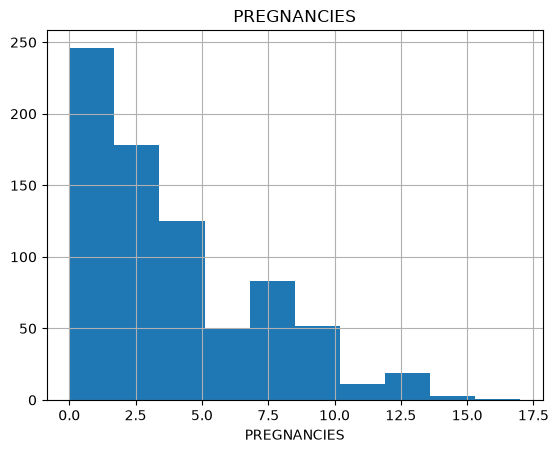

count    768.000000
mean     120.894531
std       31.972618
min        0.000000
5%        79.000000
10%       85.000000
20%       95.000000
30%      102.000000
40%      109.000000
50%      117.000000
60%      125.000000
70%      134.000000
80%      147.000000
90%      167.000000
95%      181.000000
99%      196.000000
max      199.000000
Name: GLUCOSE, dtype: float64


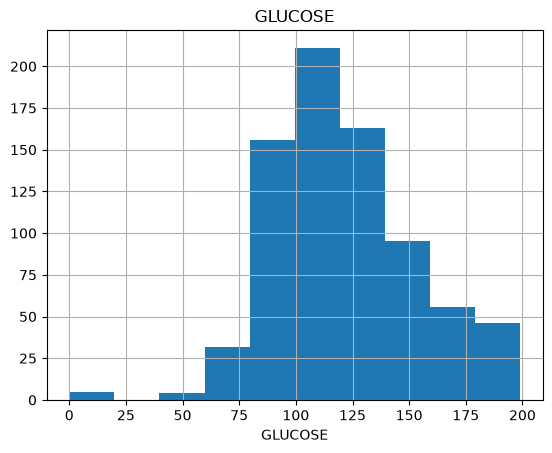

count    768.000000
mean      69.105469
std       19.355807
min        0.000000
5%        38.700000
10%       54.000000
20%       60.000000
30%       64.000000
40%       68.000000
50%       72.000000
60%       74.000000
70%       78.000000
80%       82.000000
90%       88.000000
95%       90.000000
99%      106.000000
max      122.000000
Name: BLOODPRESSURE, dtype: float64


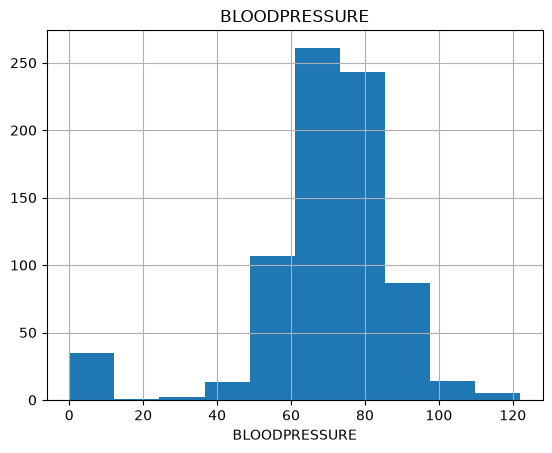

count    768.000000
mean      20.536458
std       15.952218
min        0.000000
5%         0.000000
10%        0.000000
20%        0.000000
30%        8.200000
40%       18.000000
50%       23.000000
60%       27.000000
70%       31.000000
80%       35.000000
90%       40.000000
95%       44.000000
99%       51.330000
max       99.000000
Name: SKINTHICKNESS, dtype: float64


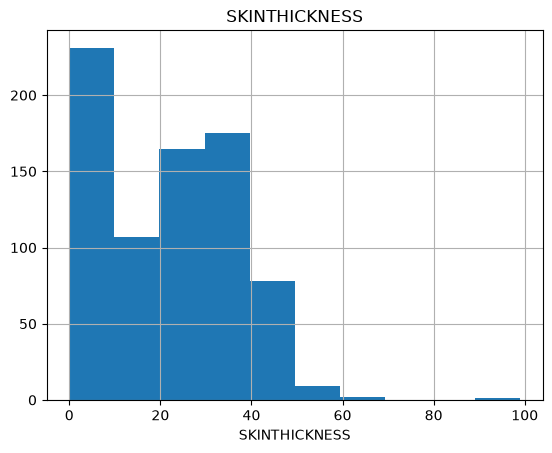

count    768.000000
mean      79.799479
std      115.244002
min        0.000000
5%         0.000000
10%        0.000000
20%        0.000000
30%        0.000000
40%        0.000000
50%       30.500000
60%       72.200000
70%      106.000000
80%      150.000000
90%      210.000000
95%      293.000000
99%      519.900000
max      846.000000
Name: INSULIN, dtype: float64


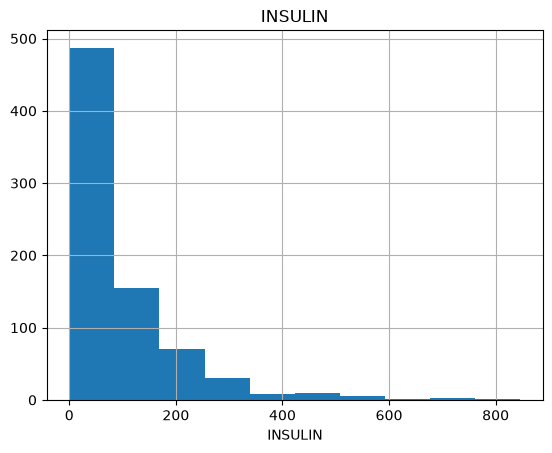

count    768.000000
mean      31.992578
std        7.884160
min        0.000000
5%        21.800000
10%       23.600000
20%       25.900000
30%       28.200000
40%       30.100000
50%       32.000000
60%       33.700000
70%       35.490000
80%       37.800000
90%       41.500000
95%       44.395000
99%       50.759000
max       67.100000
Name: BMI, dtype: float64


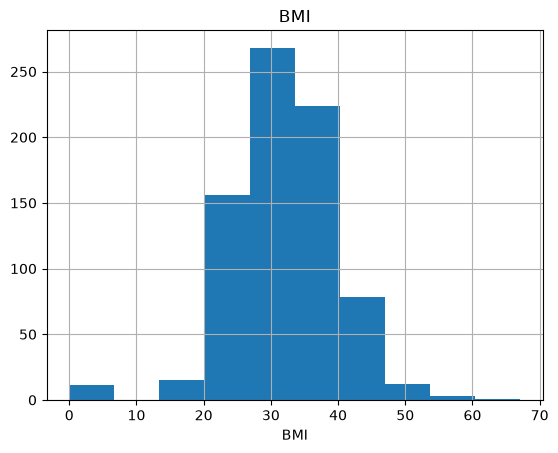

count    768.000000
mean       0.471876
std        0.331329
min        0.078000
5%         0.140350
10%        0.165000
20%        0.219400
30%        0.259000
40%        0.302800
50%        0.372500
60%        0.454200
70%        0.563700
80%        0.687000
90%        0.878600
95%        1.132850
99%        1.698330
max        2.420000
Name: DIABETESPEDIGREEFUNCTION, dtype: float64


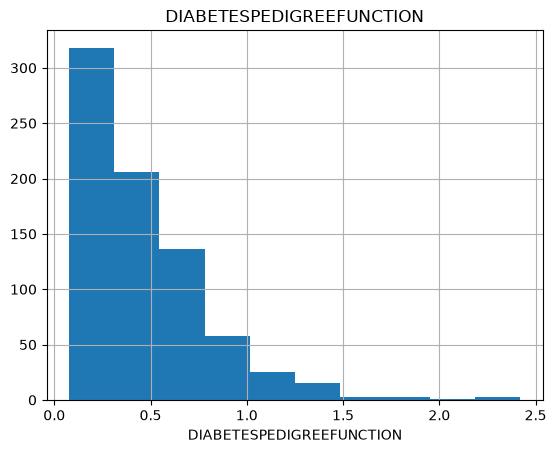

count    768.000000
mean      33.240885
std       11.760232
min       21.000000
5%        21.000000
10%       22.000000
20%       23.000000
30%       25.000000
40%       27.000000
50%       29.000000
60%       33.000000
70%       38.000000
80%       42.600000
90%       51.000000
95%       58.000000
99%       67.000000
max       81.000000
Name: AGE, dtype: float64


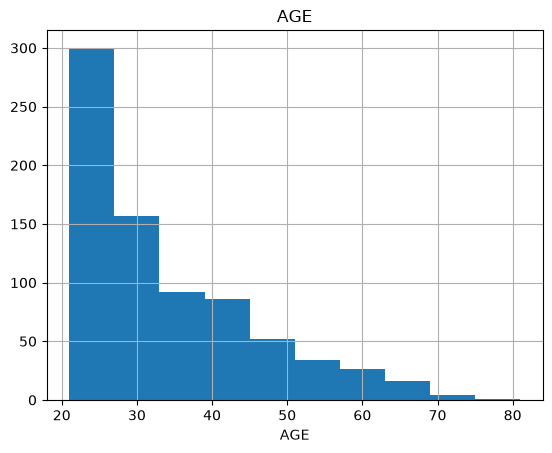

In [13]:
def num_summary(dataframe, numerical_col, plot=False):
    """
    Verilen dataframe'de, belirtilen sayısal değişkenin temel istatistiksel özetini ve yüzdelik değerlerini gösterir. 
    plot=True olarak ayarlanırsa, ilgili değişkenin histogramını çizer.

    Parametreler
    ------------
    dataframe : pandas.DataFrame
        Analizi yapılacak veri çerçevesi.
    numerical_col : str
        Temel istatistiklerin hesaplanacağı sayısal değişken ismi.
    plot : bool, opsiyonel
        Eğer True verilirse değişkenin histogramı çizilir, varsayılan olarak False.

    Kullanım
    --------
    num_summary(df, "age", plot=True)
    """
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    summary = dataframe[numerical_col].describe(quantiles).T
    print(summary)

    if plot:
        dataframe[numerical_col].hist()
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)


for col in num_cols:
    num_summary(df, col, plot=True)


### Adım 4: Hedef değişken analizi yapınız.

(Kategorik değişkenlere göre hedef değişkenin ortalaması, hedef değişkene göre numerik değişkenlerin ortalaması)

In [15]:
def target_summary_with_num(dataframe, target, numerical_col):
    """
    Belirli bir sayısal değişkenin (numerical_col), hedef değişkenin (target) her bir kategorisi
    için ortalamasını hesaplar ve çıktıyı ekrana basar.

    Parameters
    ----------
    dataframe: pd.DataFrame
        Analiz yapılacak veri seti.
    target: str
        Hedef değişkenin adı (örneğin, "survived").
    numerical_col: str
        Ortalama değeri incelenecek sayısal değişkenin adı.

    Returns
    -------
    None
        Fonksiyon yalnızca çıktıyı ekrana basar.

    Açıklama
    --------
    Bu fonksiyon, örneğin yolcuların hayatta kalma durumuna göre yaş ortalamasının nasıl değiştiğini incelememizi sağlar.
    Groupby ile hedef değişkenin gruplarına göre seçilen sayısal kolonun ortalamasını hesaplar.
    Bu şekilde, her bir hedef değişken kategorisi için sayısal değişkenin ortalamasını yorumlayabiliriz.
    """
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")

for col in num_cols:
    target_summary_with_num(df, "OUTCOME", col)


         PREGNANCIES
OUTCOME             
0           3.298000
1           4.865672


            GLUCOSE
OUTCOME            
0        109.980000
1        141.257463


         BLOODPRESSURE
OUTCOME               
0            68.184000
1            70.824627


         SKINTHICKNESS
OUTCOME               
0            19.664000
1            22.164179


            INSULIN
OUTCOME            
0         68.792000
1        100.335821


               BMI
OUTCOME           
0        30.304200
1        35.142537


         DIABETESPEDIGREEFUNCTION
OUTCOME                          
0                        0.429734
1                        0.550500


               AGE
OUTCOME           
0        31.190000
1        37.067164




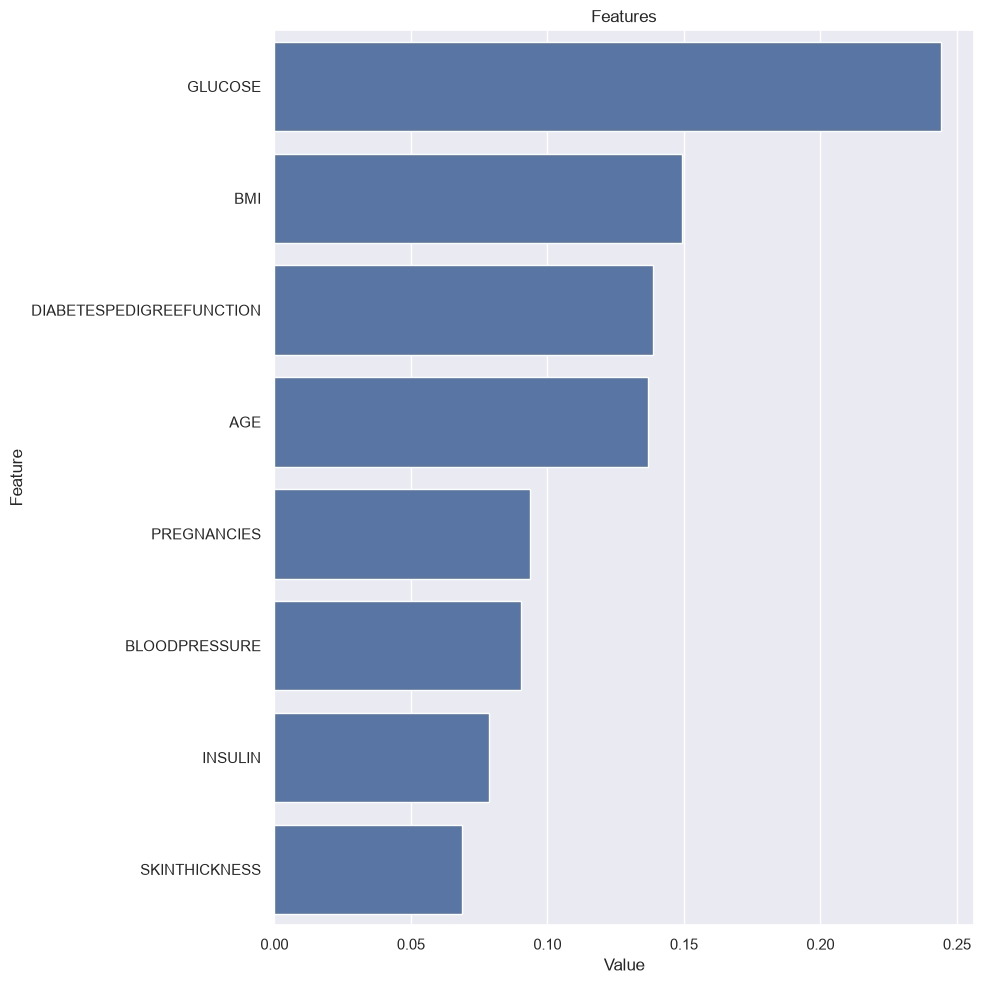

In [ ]:

# Öncelikle, hedef değişken (bağımlı değişken) olarak "OUTCOME" seçiliyor ve bağımsız değişkenler ile ayrıştırılıyor.
y = df["OUTCOME"]  # Outcome (diyabet olup olmama durumu)
X = df.drop("OUTCOME", axis=1)  # Diğer değişkenler (bağımsız değişkenler)

# Veri eğitim- test olarak ikiye ayrılıyor.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)

# RandomForestClassifier modeli tanımlanıp eğitim verisine fit ediliyor ve test setinde tahmin yapılıyor.
rf_model = RandomForestClassifier(random_state=46).fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# Özellik (değişken) önem grafiklerini görselleştirmek için yardımcı bir fonksiyon tanımlanıyor.
def plot_importance(model, features, num=len(X), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(10, 10))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value",
                                                                     ascending=False)[0:num])
    plt.title('Features')
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig('importances.png')

# Eğitim sonunda, Random Forest modelinin hangi değişkenlere ne ölçüde önem verdiği görselleştiriliyor.
plot_importance(rf_model, X)

### Adım 5: Aykırı gözlem analizi yapınız.

In [17]:
def outlier_thresholds(dataframe, col_name):
    """
    Verilen bir dataframe ve değişken ismi için aykırı değer sınırlarını (alt ve üst limit) hesaplar.
    Alt ve üst limitleri çeyreklikler ve IQR (interquartile range) kullanarak belirler.
    
    Parameters:
        dataframe (pd.DataFrame): İşlem yapılacak veri çerçevesi.
        col_name (str): Sınırları hesaplanacak değişkenin ismi.
        
    Returns:
        tuple: (alt limit, üst limit)
    """
    quartile1 = dataframe[col_name].quantile(0.25)
    quartile3 = dataframe[col_name].quantile(0.75)
    interquantile_range = quartile3 - quartile1
    low_limit = quartile1 - 1.5 * interquantile_range
    up_limit = quartile3 + 1.5 * interquantile_range
    return low_limit, up_limit


def check_outlier(dataframe, col_name):
    """
    Verilen veri çerçevesinde (dataframe) ve belirtilen değişkende (col_name) aykırı değer (outlier) olup olmadığını kontrol eder.
    Aykırı değerler, çeyreklikler arası mesafe (IQR) yöntemiyle saptanır.
    Eğer en az bir aykırı değer varsa True, yoksa False döner.

    Parametreler:
        dataframe (pd.DataFrame): Kontrol edilecek veri çerçevesi.
        col_name (str): Kontrol edilecek sütunun adı.

    Dönüş:
        bool: Aykırı değer varsa True, yoksa False.
    """
    # Alt ve üst sınırı hesapla
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    
    # Aykırı değerleri bul: sütundaki değerlerden sınırların dışında kalanları filtrele
    outliers = dataframe[(dataframe[col_name] < low_limit) | (dataframe[col_name] > up_limit)]
    
    # En az 1 aykırı değer varsa True döndür, yoksa False döndür
    return outliers.shape[0] > 0

In [18]:
for col in num_cols:
    print(col, check_outlier(df, col))


PREGNANCIES True
GLUCOSE True
BLOODPRESSURE True
SKINTHICKNESS True
INSULIN True
BMI True
DIABETESPEDIGREEFUNCTION True
AGE True


In [19]:
# Aykırı Değerlerin Kendilerine Erişmek
def grab_outliers(dataframe, col_name, index=False):
    """
    Belirtilen değişkenin (col_name) aykırı değerlerini veri setinden bulup gösterir.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        İncelenecek veri seti.
    col_name : str
        Aykırı değerleri bulunacak değişkenin ismi.
    index : bool, optional
        True ise, aykırı gözlem indexlerini döndürür. False ise yalnızca aykırı gözlemleri yazdırır.

    Dönüş
    -------
    None veya pd.Index:
        index=True ise, aykırı gözlem indexlerini döndürür. Aksi halde None döner.

    Açıklama
    -------
    Değişkenin alt ve üst aykırı sınırları outlier_thresholds fonksiyonu ile bulunur.
    Eğer aykırı değer sayısı 10'dan fazlaysa, sadece ilk 5'i gösterilir.
    Aykırı değerlerin indexi istenirse, pandas Index nesnesi olarak döndürülür.
    """
    # Değişkenin alt (low) ve üst (up) aykırı değer eşiklerini hesapla
    low, up = outlier_thresholds(dataframe, col_name)

    # Eğer ilgili değişkende aykırı gözlem sayısı 10'dan fazlaysa, ilk 5 aykırı değeri yazdırır
    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    # Eğer 10 veya daha az aykırı gözlem varsa, hepsini yazdırır
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    # index parametresi True ise, aykırı değerlerin indekslerini döndürür
    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

for col in num_cols:
    print(col, grab_outliers(df, col, index=True))



     PREGNANCIES  GLUCOSE  BLOODPRESSURE  SKINTHICKNESS  INSULIN   BMI  \
88            15      136             70             32      110  37.1   
159           17      163             72             41      114  40.9   
298           14      100             78             25      184  36.6   
455           14      175             62             30        0  33.6   

     DIABETESPEDIGREEFUNCTION  AGE  OUTCOME  
88                      0.153   43        1  
159                     0.817   47        1  
298                     0.412   46        1  
455                     0.212   38        1  
PREGNANCIES Index([88, 159, 298, 455], dtype='int64')
     PREGNANCIES  GLUCOSE  BLOODPRESSURE  SKINTHICKNESS  INSULIN   BMI  \
75             1        0             48             20        0  24.7   
182            1        0             74             20       23  27.7   
342            1        0             68             35        0  32.0   
349            5        0             80         

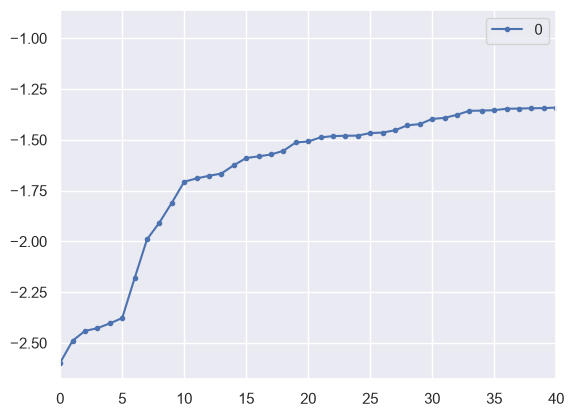

In [20]:
# LocalOutlierFactor algoritmasını kullanarak veri setindeki aykırı gözlemleri tespit ediyoruz.
# n_neighbors=20 ifadesiyle her gözlem için 20 komşusuna göre aykırılık dereceleri hesaplanacak.
clf = LocalOutlierFactor(n_neighbors=20) 

# Modeli verimize fit ediyor ve her gözlemin aykırı (outlier) olup olmadığını belirlemek için fit_predict kullanılıyor.
clf.fit_predict(df)

# Algoritmanın her gözlem için ürettiği negatif aykırılık faktörünü (negative_outlier_factor_) çekiyoruz.
# Bu değer, gözlemin ne derece aykırı olduğunun bir ölçüsüdür; daha düşük (daha negatif) olması, daha yüksek aykırılık anlamına gelir.
df_scores = clf.negative_outlier_factor_

# Elde edilen aykırı skorlarını küçükten büyüğe sıralayıp bir DataFrame'e çeviriyoruz.
scores = pd.DataFrame(np.sort(df_scores))

# Skorları görselleştirmek için ilk 40 gözlemi çizdiriyoruz.
# xlim=[0,40] kodda 0'dan 40'a kadarki değerleri gösterir.
scores.plot(stacked=True, xlim=[0, 40], style=".-")

# Grafiği ekrana bastırıyoruz.
plt.show()

### Adım 6: Eksik gözlem analizi yapınız.

In [21]:
def missing_values_table(dataframe, na_name=False):
    """
    Dataframe'deki eksik değerlerin analizini yapar ve özet bir tablo halinde gösterir.

    Args:
        dataframe (pd.DataFrame): İncelenecek veri seti.
        na_name (bool): True verilirse yalnızca eksik değere sahip kolon isimlerini döndürür.

    Returns:
        Eksik değere sahip kolon isimleri (opsiyonel).
    """
    # Eksik değere sahip kolonları bulma
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    # Eksik değer sayısı (n_miss) ve toplam içindeki oranı (ratio) hesaplama
    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)

    # Sonuçları tek tabloda birleştirme
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['Eksik Değer Sayısı', 'Oran (%)'])

    # Tablonun ekrana yazdırılması
    print(missing_df, end="\n")

    # Eğer istenirse, eksik değere sahip kolonların listesini döndürür
    if na_name:
        return na_columns

missing_values_table(df)

Empty DataFrame
Columns: [Eksik Değer Sayısı, Oran (%)]
Index: []


### Adım 7: Korelasyon analizi yapınız.

In [ ]:
# Korelasyon analizi için, sadece sayısal değişkenler arasındaki ilişkileri inceliyoruz.
# Bunun için, pandas'ın .corr() fonksiyonu ile bir korelasyon matrisi oluşturulur.
corr = df[num_cols].corr()

# Oluşan korelasyon matrisi, değişken çiftleri arasındaki pozitif veya negatif ilişki seviyesini gösterir.
# Korelasyon katsayısı 1'e ne kadar yakınsa pozitif güçlü bir ilişki, -1'e yaklaştıkça negatif güçlü bir ilişki olduğunu gösterir.
# 0 ise iki değişken arasında doğrusal bir ilişki olmadığını ifade eder.
corr

,PREGNANCIES,GLUCOSE,BLOODPRESSURE,SKINTHICKNESS,INSULIN,BMI,DIABETESPEDIGREEFUNCTION,AGE
PREGNANCIES,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341
GLUCOSE,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514
BLOODPRESSURE,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528
SKINTHICKNESS,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970
INSULIN,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242
DIABETESPEDIGREEFUNCTION,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561
AGE,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000


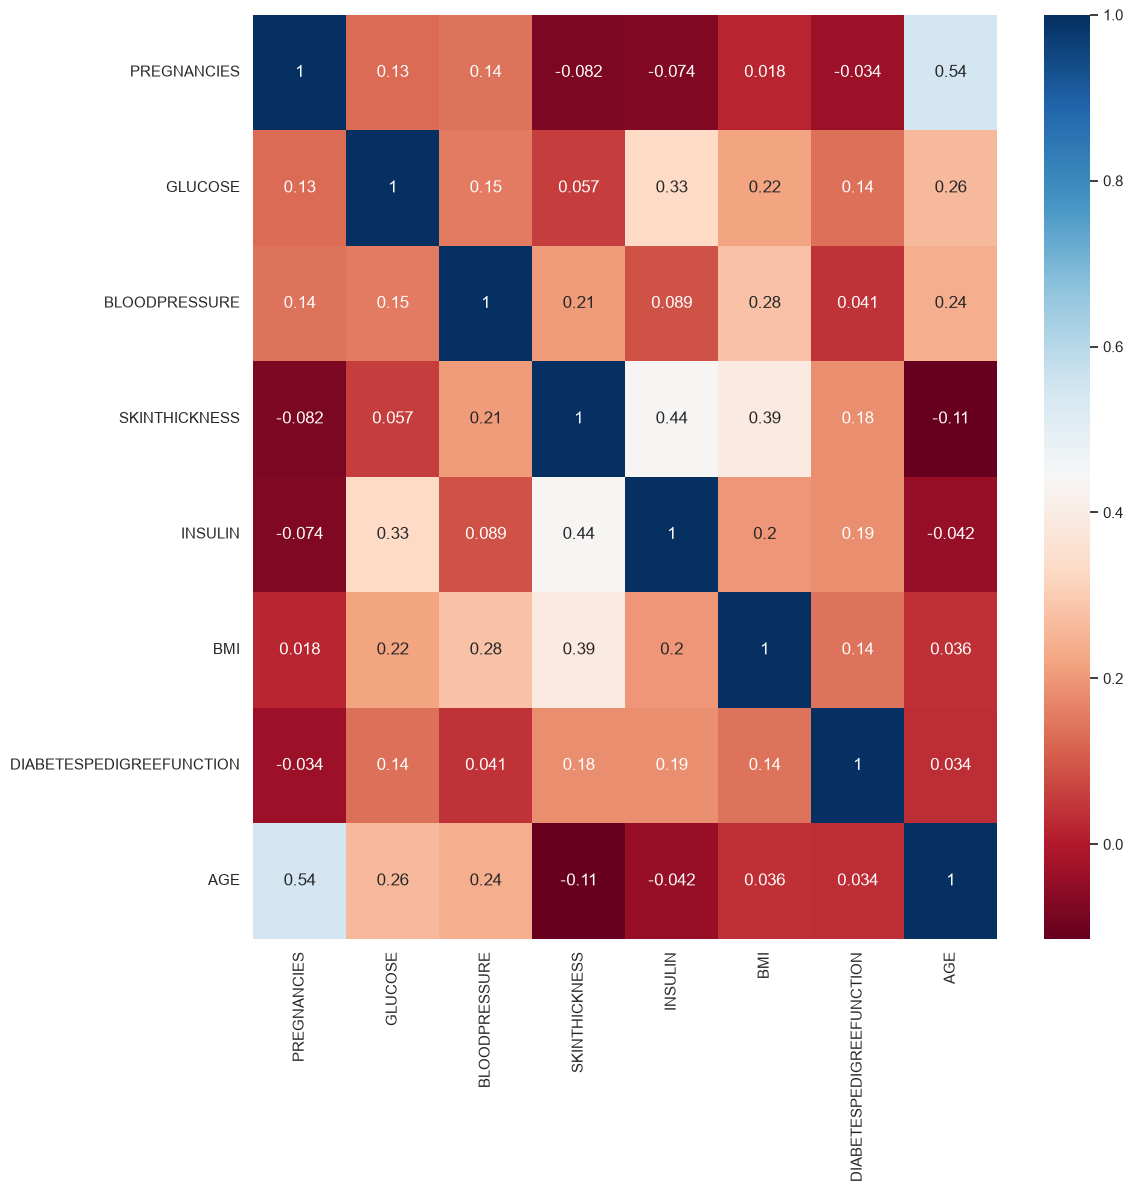

In [23]:
sns.set(rc={'figure.figsize':(12,12)})
sns.heatmap(corr, cmap="RdBu", annot=True)
plt.show()

# Görev 2: Feature Engineering

### Adım 1: Eksik ve aykırı değerler için gerekli işlemleri yapınız.

Veri setinde eksik gözlem bulunmamakta ama Glikoz, Insulin vb. değişkenlerde 0 değeri içeren gözlem birimleri eksik değeri ifade ediyor olabilir. Örneğin; bir kişinin glikoz veya insulin değeri 0 olamayacaktır. Bu durumu dikkate alarak sıfır değerlerini ilgili değerlerde NaN olarak atama yapıp sonrasında eksik değerlere işlemleri uygulayabilirsiniz.

In [ ]:
# Bu adımda eksik değerleri dolduruyoruz.
# Sayısal değişkenler için eksik değerleri (NaN) değişkenin ortalaması ile dolduruyoruz.
df = df.apply(lambda x: x.fillna(x.mean()) if x.dtype != "O" else x, axis=0)

# Kategorik değişkenlerde eğer kategori sayısı 10 veya daha az ise, eksik değerleri en sık tekrar eden değer (mod) ile dolduruyoruz.
df = df.apply(lambda x: x.fillna(x.mode()[0]) if (x.dtype == "O" and len(x.unique()) <= 10) else x, axis=0)

# Son olarak eksik değer kontrolü yapıyoruz. Her sütunda kaç eksik değer kaldığına bakıyoruz.
df.isnull().sum()

PREGNANCIES                 0
GLUCOSE                     0
BLOODPRESSURE               0
SKINTHICKNESS               0
INSULIN                     0
BMI                         0
DIABETESPEDIGREEFUNCTION    0
AGE                         0
OUTCOME                     0
dtype: int64

In [25]:
def missing_vs_target(dataframe, target, na_columns):
    temp_df = dataframe.copy()  # Orijinal veri setinin bir kopyası alınır.

    # Eksikliği bayraklayan (flag) sütunlar oluşturuluyor:
    for col in na_columns:
        temp_df[col + '_NA_FLAG'] = np.where(temp_df[col].isnull(), 1, 0)

    # Sadece oluşturulan NA flaglerini seçiyoruz:
    na_flags = temp_df.loc[:, temp_df.columns.str.contains("_NA_")].columns

    # Her eksiklik bayrağı için, gruplandırıp bağımlı değişken ortalaması (TARGET_MEAN) ve count (Count) veriliyor.
    for col in na_flags:
        print(pd.DataFrame({
            "TARGET_MEAN": temp_df.groupby(col)[target].mean(),
            "Count": temp_df.groupby(col)[target].count()
        }), end="\n\n\n")

zero_to_nan_cols = ['GLUCOSE', 'BLOODPRESSURE', 'SKINTHICKNESS', 'INSULIN', 'BMI']
for col in zero_to_nan_cols:
    df[col] = df[col].replace({'0':np.nan, 0:np.nan})

missing_values_table(df)

               Eksik Değer Sayısı  Oran (%)
INSULIN                       374     48.70
SKINTHICKNESS                 227     29.56
BLOODPRESSURE                  35      4.56
BMI                            11      1.43
GLUCOSE                         5      0.65


In [26]:
missing_vs_target(df, "OUTCOME", zero_to_nan_cols)

                 TARGET_MEAN  Count
GLUCOSE_NA_FLAG                    
0                   0.348624    763
1                   0.400000      5


                       TARGET_MEAN  Count
BLOODPRESSURE_NA_FLAG                    
0                         0.343793    733
1                         0.457143     35


                       TARGET_MEAN  Count
SKINTHICKNESS_NA_FLAG                    
0                         0.332717    541
1                         0.387665    227


                 TARGET_MEAN  Count
INSULIN_NA_FLAG                    
0                   0.329949    394
1                   0.368984    374


             TARGET_MEAN  Count
BMI_NA_FLAG                    
0               0.351387    757
1               0.181818     11




In [28]:
def replace_with_thresholds(dataframe, variable):
    """
    Belirtilen değişkenin (variable) aykırı değerlerini alt ve üst sınırlarla değiştirir.

    Parametreler
    ----------
    dataframe : pd.DataFrame
        Aykırı değerleri değiştirilecek veri çerçevesi.
    variable : str
        Değiştirilecek değişkenin ismi.

    Dönüş Değeri
    -------------
    pd.DataFrame
        Aykırı değerleri içermeyen yeni veri çerçevesi.

    Açıklama
    ----------
    Bu fonksiyon, outlier_thresholds fonksiyonu ile belirlenen alt ve üst eşik değerlerine göre,  ilgili sütunda (variable) eşiklerin dışında kalan (aykırı) gözlemleri veri setinden çıkarır.
    Sonuç olarak, aykırı değerlerden arındırılmış bir DataFrame elde edilir.
    """

    # Alt ve üst aykırı değer eşiklerini belirle
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    
    # İlgili sütunun tipini kontrol et ve eğer tam sayı ise float'a çevir
    if pd.api.types.is_integer_dtype(dataframe[variable]):
        dataframe[variable] = dataframe[variable].astype(float)

    # Eşiklerin dışında kalan aykırı değerleri filtrele
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit
    
    # Yeni DataFrame'i döndür
    return dataframe

for col in num_cols:
    replace_with_thresholds(df, col)

for col in num_cols:
    print(col, check_outlier(df, col))


PREGNANCIES False
GLUCOSE False
BLOODPRESSURE False
SKINTHICKNESS False
INSULIN False
BMI False
DIABETESPEDIGREEFUNCTION False
AGE False


In [32]:
# Bu bölümde veri setindeki eksik değerler, ilgili sütunların ortalama değerleriyle doldurulmaktadır.
# Özellikle "INSULIN", "SKINTHICKNESS", "BMI", "BLOODPRESSURE" ve "GLUCOSE" sütunlarında eksik değerler tespit edilmişse,
# her birinin ortalaması hesaplanır ve eksik (NaN) gözlemler bu ortalama değer ile yer değiştirir.

cols_with_na = ["INSULIN", "SKINTHICKNESS", "BMI", "BLOODPRESSURE", "GLUCOSE"]
for col in cols_with_na:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

# Eksik değerlerin doldurulmasından sonra, veri setinde aykırı (outlier) gözlemleri tespit etmek amacıyla
# LocalOutlierFactor (LOF) algoritması uygulanmaktadır. n_neighbors=20 parametresi ile LOF modeli tanımlanır.
# .fit_predict(df) fonksiyonu ile veri setindeki her bir gözlem için aykırılık skorları hesaplanır ve
# gözlem aykırı ise -1, değilse 1 olarak etiketlenir.

# LOF algoritması çalıştırılmadan önce, veri setinde hiç eksik değer kalmadığını doğrulamak önemlidir.
if df.isnull().sum().sum() == 0:
    clf = LocalOutlierFactor(n_neighbors=20)
    lof_labels = clf.fit_predict(df)
    print(lof_labels)
else:
    raise ValueError("Veri setinde eksik (NaN) değerler bulunmaktadır. LOF algoritmasını çalıştırmadan önce eksik değerleri doldurun.")

[ 1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1 -1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1

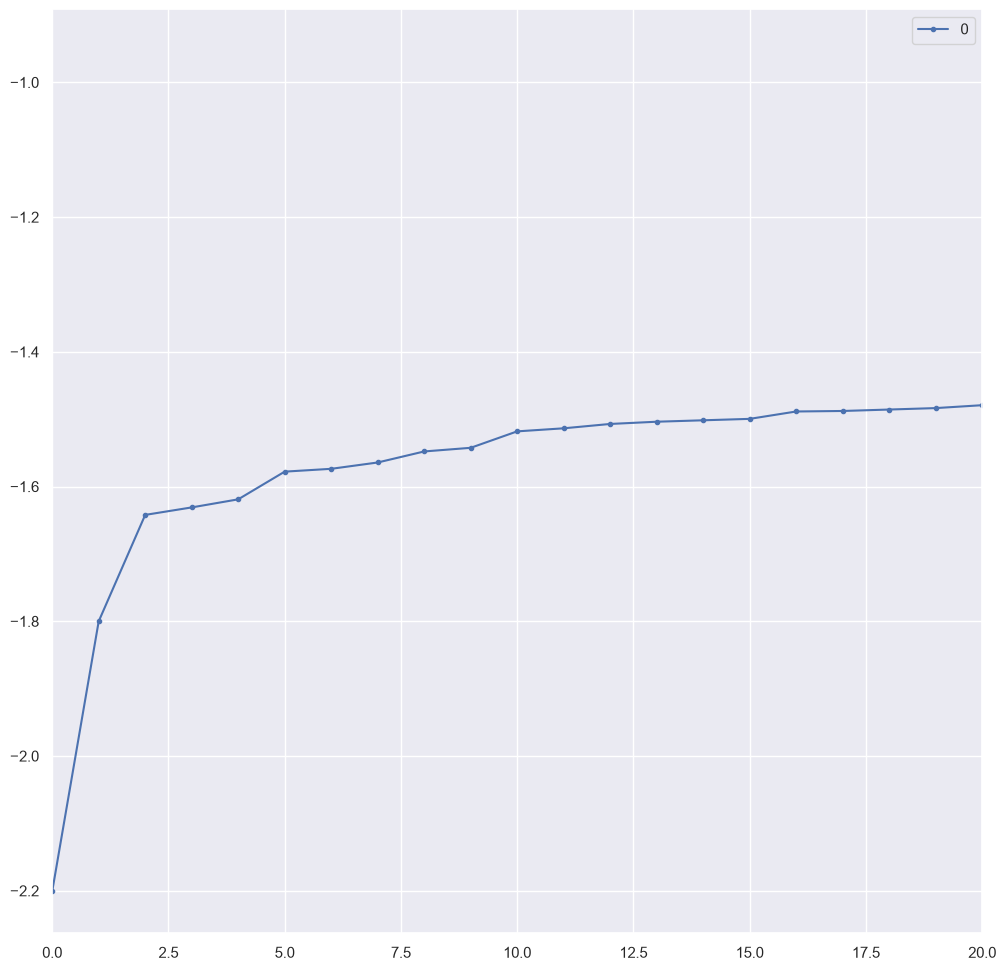

In [31]:
df_scores = clf.negative_outlier_factor_
sorted_df_scores = np.sort(df_scores)
scores = pd.DataFrame(sorted_df_scores)
scores.plot(stacked=True, xlim=[0, 20], style='.-')
plt.show()

In [33]:
th = sorted_df_scores[7]
th

np.float64(-1.564318488146627)

In [34]:
df.describe([0.01, 0.05, 0.75, 0.90, 0.99]).T

,count,mean,std,min,1%,5%,75%,90%,99%,max
PREGNANCIES,768.0,3.837240,3.344157,0.000,0.00000,0.00000,6.00000,9.0000,13.0000,13.500
GLUCOSE,768.0,121.686763,30.435949,44.000,67.67000,80.00000,140.25000,167.0000,196.0000,199.000
BLOODPRESSURE,768.0,72.375171,11.696835,40.000,44.00000,52.00000,80.00000,88.0000,104.0000,104.000
SKINTHICKNESS,768.0,29.059150,8.438759,7.000,10.00000,14.35000,32.00000,40.0000,51.3300,57.000
INSULIN,768.0,146.500000,64.672728,14.000,24.34000,50.00000,146.50000,210.0000,360.6250,360.625
BMI,768.0,32.394716,6.667462,18.200,19.50000,22.23500,36.60000,41.5000,50.0825,50.250
DIABETESPEDIGREEFUNCTION,768.0,0.458914,0.285596,0.078,0.09468,0.14035,0.62625,0.8786,1.2000,1.200
AGE,768.0,33.199870,11.628404,21.000,21.00000,21.00000,41.00000,51.0000,66.5000,66.500
OUTCOME,768.0,0.348958,0.476951,0.000,0.00000,0.00000,1.00000,1.0000,1.0000,1.000


In [ ]:
df.drop(axis=0, labels=df[df_scores < th].index, inplace=True) # aykırı değerleri sil

### Adım 2: Yeni değişkenler oluşturunuz.

In [36]:
# Yaşa göre kategorik değişken
df.loc[(df["AGE"] >= 21) & (df["AGE"] < 50), "NEW_AGE_CAT"] = "mature"
df.loc[(df["AGE"] >= 50), "NEW_AGE_CAT"] = "senior"

# BMI'ye göre kategorik değişken
df['NEW_BMI'] = pd.cut(
    x=df['BMI'],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=["Underweight", "Healthy", "Overweight", "Obese"]
)

# Glukoz değerini kategorik değişkene çevirme
df["NEW_GLUCOSE"] = pd.cut(
    x=df["GLUCOSE"],
    bins=[0, 140, 200, 300],
    labels=["Normal", "Prediabetes", "Diabetes"]
)

# Yaş ve BMI'yı birlikte değerlendiren yeni kategorik değişken
df.loc[(df["BMI"] < 18.5) & ((df["AGE"] >= 21) & (df["AGE"] < 50)), "NEW_AGE_BMI_NOM"] = "underweightmature"
df.loc[(df["BMI"] < 18.5) & (df["AGE"] >= 50), "NEW_AGE_BMI_NOM"] = "underweightsenior"
df.loc[((df["BMI"] >= 18.5) & (df["BMI"] < 25)) & ((df["AGE"] >= 21) & (df["AGE"] < 50)), "NEW_AGE_BMI_NOM"] = "healthymature"
df.loc[((df["BMI"] >= 18.5) & (df["BMI"] < 25)) & (df["AGE"] >= 50), "NEW_AGE_BMI_NOM"] = "healthysenior"
df.loc[((df["BMI"] >= 25) & (df["BMI"] < 30)) & ((df["AGE"] >= 21) & (df["AGE"] < 50)), "NEW_AGE_BMI_NOM"] = "overweightmature"
df.loc[((df["BMI"] >= 25) & (df["BMI"] < 30)) & (df["AGE"] >= 50), "NEW_AGE_BMI_NOM"] = "overweightsenior"
df.loc[(df["BMI"] > 30) & ((df["AGE"] >= 21) & (df["AGE"] < 50)), "NEW_AGE_BMI_NOM"] = "obesemature"
df.loc[(df["BMI"] > 30) & (df["AGE"] >= 50), "NEW_AGE_BMI_NOM"] = "obesesenior"

# Yaş ve Glukoz değerini birlikte değerlendiren yeni kategorik değişken
df.loc[(df["GLUCOSE"] < 70) & ((df["AGE"] >= 21) & (df["AGE"] < 50)), "NEW_AGE_GLUCOSE_NOM"] = "lowmature"
df.loc[(df["GLUCOSE"] < 70) & (df["AGE"] >= 50), "NEW_AGE_GLUCOSE_NOM"] = "lowsenior"
df.loc[((df["GLUCOSE"] >= 70) & (df["GLUCOSE"] < 100)) & ((df["AGE"] >= 21) & (df["AGE"] < 50)), "NEW_AGE_GLUCOSE_NOM"] = "normalmature"
df.loc[((df["GLUCOSE"] >= 70) & (df["GLUCOSE"] < 100)) & (df["AGE"] >= 50), "NEW_AGE_GLUCOSE_NOM"] = "normalsenior"
df.loc[((df["GLUCOSE"] >= 100) & (df["GLUCOSE"] <= 125)) & ((df["AGE"] >= 21) & (df["AGE"] < 50)), "NEW_AGE_GLUCOSE_NOM"] = "hiddenmature"
df.loc[((df["GLUCOSE"] >= 100) & (df["GLUCOSE"] <= 125)) & (df["AGE"] >= 50), "NEW_AGE_GLUCOSE_NOM"] = "hiddensenior"
df.loc[(df["GLUCOSE"] > 125) & ((df["AGE"] >= 21) & (df["AGE"] < 50)), "NEW_AGE_GLUCOSE_NOM"] = "highmature"
df.loc[(df["GLUCOSE"] > 125) & (df["AGE"] >= 50), "NEW_AGE_GLUCOSE_NOM"] = "highsenior"

# İnsülin skorunu belirleme fonksiyonu
def set_INSULIN(dataframe, col_name="INSULIN"):
    if 16 <= dataframe[col_name] <= 166:
        return "Normal"
    else:
        return "Abnormal"

df["NEW_INSULIN_SCORE"] = df.apply(set_INSULIN, axis=1)

# Etkileşimli değişkenler
df["NEW_GLUCOSE*INSULIN"] = df["GLUCOSE"] * df["INSULIN"]
df["NEW_GLUCOSE*PREGNANCIES"] = df["GLUCOSE"] * df["PREGNANCIES"]

df.head()

,PREGNANCIES,GLUCOSE,BLOODPRESSURE,SKINTHICKNESS,INSULIN,BMI,DIABETESPEDIGREEFUNCTION,AGE,OUTCOME,NEW_AGE_CAT,NEW_BMI,NEW_GLUCOSE,NEW_AGE_BMI_NOM,NEW_AGE_GLUCOSE_NOM,NEW_INSULIN_SCORE,NEW_GLUCOSE*INSULIN,NEW_GLUCOSE*PREGNANCIES
0,6.0,148.0,72.0,35.00000,146.5,33.6,0.627,50.0,1,senior,Obese,Prediabetes,obesesenior,highsenior,Normal,21682.0,888.0
1,1.0,85.0,66.0,29.00000,146.5,26.6,0.351,31.0,0,mature,Overweight,Normal,overweightmature,normalmature,Normal,12452.5,85.0
2,8.0,183.0,64.0,29.05915,146.5,23.3,0.672,32.0,1,mature,Healthy,Prediabetes,healthymature,highmature,Normal,26809.5,1464.0
3,1.0,89.0,66.0,23.00000,94.0,28.1,0.167,21.0,0,mature,Overweight,Normal,overweightmature,normalmature,Normal,8366.0,89.0
4,0.0,137.0,40.0,35.00000,168.0,43.1,1.200,33.0,1,mature,Obese,Normal,obesemature,highmature,Abnormal,23016.0,0.0


### Adım 3: Encoding işlemlerini gerçekleştiriniz.

In [ ]:

def label_encoder(dataframe, binary_col):
    # LabelEncoder nesnesi oluşturulur.
    labelencoder = LabelEncoder()
    # fit_transform ile ilgili kolon sayısal değerlere dönüştürülür ve orijinal kolona atanır.
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    # Dönüştürülmüş veri çerçevesi fonksiyondan döndürülür.
    return dataframe

# İkili (binary) kategorik değişkenleri seçelim:
# Burada, veri çerçevesindeki (df) tüm sütunlar arasında hem veri tipi int veya float olmayan
# hem de yalnızca iki benzersiz (unique) değeri olan sütunlar filtrelenerek 'binaryCols' listesine atanıyor.
binaryCols = [col for col in df.columns if df[col].dtype not in [int, float] and df[col].nunique() == 2]
binaryCols  # Bu kod ile seçilen ikili kategorik değişkenleri ekrana yazdırıyoruz.

['NEW_AGE_CAT', 'NEW_GLUCOSE', 'NEW_INSULIN_SCORE']

In [39]:
for col in binaryCols:
    label_encoder(df, col)
df.head()

,PREGNANCIES,GLUCOSE,BLOODPRESSURE,SKINTHICKNESS,INSULIN,BMI,DIABETESPEDIGREEFUNCTION,AGE,OUTCOME,NEW_AGE_CAT,NEW_BMI,NEW_GLUCOSE,NEW_AGE_BMI_NOM,NEW_AGE_GLUCOSE_NOM,NEW_INSULIN_SCORE,NEW_GLUCOSE*INSULIN,NEW_GLUCOSE*PREGNANCIES
0,6.0,148.0,72.0,35.00000,146.5,33.6,0.627,50.0,1,1,Obese,1,obesesenior,highsenior,1,21682.0,888.0
1,1.0,85.0,66.0,29.00000,146.5,26.6,0.351,31.0,0,0,Overweight,0,overweightmature,normalmature,1,12452.5,85.0
2,8.0,183.0,64.0,29.05915,146.5,23.3,0.672,32.0,1,0,Healthy,1,healthymature,highmature,1,26809.5,1464.0
3,1.0,89.0,66.0,23.00000,94.0,28.1,0.167,21.0,0,0,Overweight,0,overweightmature,normalmature,1,8366.0,89.0
4,0.0,137.0,40.0,35.00000,168.0,43.1,1.200,33.0,1,0,Obese,0,obesemature,highmature,0,23016.0,0.0


In [40]:
def rare_analyser(dataframe, target, cat_cols):
    for col in cat_cols:
        # Sütundaki farklı kategori (unique) sayısını yazdır
        print(col, ":", len(dataframe[col].value_counts()))
        # Her bir kategori için:
        #   COUNT: Adet
        #   RATIO: Toplam içindeki oran
        #   TARGET_MEAN: O kategoriye sahip satırlarda hedef değişkenin ortalaması
        print(
            pd.DataFrame({
                "COUNT": dataframe[col].value_counts(),
                "RATIO": dataframe[col].value_counts() / len(dataframe),
                "TARGET_MEAN": dataframe.groupby(col)[target].mean()
            }),
            end="\n\n\n"
        )

# Fonksiyon çağırımı: Tüm kategorik sütunlar için rare_analyser fonksiyonu kullanılıyor.
rare_analyser(df, "OUTCOME", binaryCols)

NEW_AGE_CAT : 2
             COUNT     RATIO  TARGET_MEAN
NEW_AGE_CAT                              
0              674  0.885677     0.330861
1               87  0.114323     0.494253


NEW_GLUCOSE : 2
             COUNT     RATIO  TARGET_MEAN
NEW_GLUCOSE                              
0              571  0.750329     0.238179
1              190  0.249671     0.684211


NEW_INSULIN_SCORE : 2
                   COUNT     RATIO  TARGET_MEAN
NEW_INSULIN_SCORE                              
0                    132  0.173456     0.522727
1                    629  0.826544     0.313196




In [41]:
def rare_encoder(dataframe, rare_perc):
    # Orijinal veri setini kopyalarız, böylece ana veri etkilenmez.
    temp_df = dataframe.copy()

    # 1. Adım: Nadiren görülen kategori barındıran değişkenleri tespit et.
    #   - Sadece tipik olarak 'O' (object) tipinde olan, yani kategorik olan değişkenlere bakılır.
    #   - Her değişken için dağılım oranı (value_counts() / toplam gözlem sayısı) rare_perc değerinden küçük olanlar nadir (rare) olarak kabul edilir.
    rare_columns = [col for col in temp_df.columns 
                   if temp_df[col].dtypes == 'O'
                   and (temp_df[col].value_counts() / len(temp_df) < rare_perc).any(axis=None)]

    # 2. Adım: Tespit edilen her nadir kategorili sütunda...
    for var in rare_columns:
        # Sütundaki her bir kategorinin oranını hesapla.
        tmp = temp_df[var].value_counts() / len(temp_df)
        # Oranı rare_perc değerinin altında olan kategori isimlerini ('etiketleri') seçiyoruz.
        rare_labels = tmp[tmp < rare_perc].index
        # Bu etiketlere sahip gözlem değerlerini 'Rare' ile değiştiriyoruz.
        temp_df[var] = np.where(temp_df[var].isin(rare_labels), 'Rare', temp_df[var])

    # Fonksiyonun çıktısı, nadir kategoriler 'Rare' etiketiyle birleştirilmiş yeni bir DataFrame'dir.
    return temp_df


def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    """
    Belirtilen kolonlara One-Hot Encoding uygular.

    Args:
        dataframe (pd.DataFrame): Dönüştürülecek veri çerçevesi.
        categorical_cols (list): Kategorik değişkenlerin listesi.
        drop_first (bool, optional): İlk kategoriyi bırakıp bırakmama tercihi. Varsayılan: True

    Returns:
        pd.DataFrame: Dummy değişkenlerle dönüştürülmüş yeni veri çerçevesi.
    """
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

ohe_cols = [col for col in df.columns if 10 >= df[col].nunique() > 2]
ohe_cols

['NEW_BMI', 'NEW_AGE_BMI_NOM', 'NEW_AGE_GLUCOSE_NOM']

In [42]:
df = one_hot_encoder(df, ohe_cols)
df.head()

,PREGNANCIES,GLUCOSE,BLOODPRESSURE,SKINTHICKNESS,INSULIN,BMI,DIABETESPEDIGREEFUNCTION,AGE,OUTCOME,NEW_AGE_CAT,...,NEW_AGE_BMI_NOM_obesesenior,NEW_AGE_BMI_NOM_overweightmature,NEW_AGE_BMI_NOM_overweightsenior,NEW_AGE_BMI_NOM_underweightmature,NEW_AGE_GLUCOSE_NOM_hiddensenior,NEW_AGE_GLUCOSE_NOM_highmature,NEW_AGE_GLUCOSE_NOM_highsenior,NEW_AGE_GLUCOSE_NOM_lowmature,NEW_AGE_GLUCOSE_NOM_normalmature,NEW_AGE_GLUCOSE_NOM_normalsenior
0,6.0,148.0,72.0,35.00000,146.5,33.6,0.627,50.0,1,1,...,True,False,False,False,False,False,True,False,False,False
1,1.0,85.0,66.0,29.00000,146.5,26.6,0.351,31.0,0,0,...,False,True,False,False,False,False,False,False,True,False
2,8.0,183.0,64.0,29.05915,146.5,23.3,0.672,32.0,1,0,...,False,False,False,False,False,True,False,False,False,False
3,1.0,89.0,66.0,23.00000,94.0,28.1,0.167,21.0,0,0,...,False,True,False,False,False,False,False,False,True,False
4,0.0,137.0,40.0,35.00000,168.0,43.1,1.200,33.0,1,0,...,False,False,False,False,False,True,False,False,False,False


### Adım 4: Numerik değişkenler için standartlaştırma yapınız.

In [43]:
# Bu adımda, numerik değişkenlerin istatistiksel olarak birbirleriyle karşılaştırılabilmesi
# ve modelde daha iyi performans gösterebilmesi için standartlaştırma işlemi uygulanıyor.
# StandardScaler tüm numerik sütunları, ortalaması 0 ve standart sapması 1 olacak şekilde dönüştürür.
scaler = StandardScaler()  # StandardScaler nesnesi oluşturuluyor.
df[num_cols] = scaler.fit_transform(df[num_cols])  # Numerik kolonlar scale ediliyor.
df.head()  # Sonuç olarak dönüştürülmüş ilk 5 satır gösteriliyor.


,PREGNANCIES,GLUCOSE,BLOODPRESSURE,SKINTHICKNESS,INSULIN,BMI,DIABETESPEDIGREEFUNCTION,AGE,OUTCOME,NEW_AGE_CAT,...,NEW_AGE_BMI_NOM_obesesenior,NEW_AGE_BMI_NOM_overweightmature,NEW_AGE_BMI_NOM_overweightsenior,NEW_AGE_BMI_NOM_underweightmature,NEW_AGE_GLUCOSE_NOM_hiddensenior,NEW_AGE_GLUCOSE_NOM_highmature,NEW_AGE_GLUCOSE_NOM_highsenior,NEW_AGE_GLUCOSE_NOM_lowmature,NEW_AGE_GLUCOSE_NOM_normalmature,NEW_AGE_GLUCOSE_NOM_normalsenior
0,0.653582,0.865918,-0.033831,0.716214,-0.005178,0.180165,0.596680,1.461898,1,1,...,True,False,False,False,False,False,True,False,False,False
1,-0.850882,-1.220399,-0.548506,-0.000205,-0.005178,-0.875293,-0.373540,-0.183818,0,0,...,False,True,False,False,False,False,False,False,True,False
2,1.255368,2.024984,-0.720065,0.006857,-0.005178,-1.372866,0.754868,-0.097202,1,0,...,False,False,False,False,False,True,False,False,False,False
3,-0.850882,-1.087935,-0.548506,-0.716625,-0.818006,-0.649124,-1.020353,-1.049985,0,0,...,False,True,False,False,False,False,False,False,True,False
4,-1.151775,0.501641,-2.778769,0.716214,0.327695,1.612571,2.610939,-0.010585,1,0,...,False,False,False,False,False,True,False,False,False,False


In [44]:
df.columns

Index(['PREGNANCIES', 'GLUCOSE', 'BLOODPRESSURE', 'SKINTHICKNESS', 'INSULIN',
       'BMI', 'DIABETESPEDIGREEFUNCTION', 'AGE', 'OUTCOME', 'NEW_AGE_CAT',
       'NEW_GLUCOSE', 'NEW_INSULIN_SCORE', 'NEW_GLUCOSE*INSULIN',
       'NEW_GLUCOSE*PREGNANCIES', 'NEW_BMI_Healthy', 'NEW_BMI_Overweight',
       'NEW_BMI_Obese', 'NEW_AGE_BMI_NOM_healthysenior',
       'NEW_AGE_BMI_NOM_obesemature', 'NEW_AGE_BMI_NOM_obesesenior',
       'NEW_AGE_BMI_NOM_overweightmature', 'NEW_AGE_BMI_NOM_overweightsenior',
       'NEW_AGE_BMI_NOM_underweightmature', 'NEW_AGE_GLUCOSE_NOM_hiddensenior',
       'NEW_AGE_GLUCOSE_NOM_highmature', 'NEW_AGE_GLUCOSE_NOM_highsenior',
       'NEW_AGE_GLUCOSE_NOM_lowmature', 'NEW_AGE_GLUCOSE_NOM_normalmature',
       'NEW_AGE_GLUCOSE_NOM_normalsenior'],
      dtype='str')

### Adım 5: Model oluşturunuz.

In [ ]:
# 1. Öncelikle hedef değişkenimizi (bağımlı değişken), yani 'OUTCOME' kolonunu y olarak belirliyoruz.
y = df["OUTCOME"]

# 2. Bağımsız değişkenlerimizi yani modelde kullanılacak girdileri X olarak tanımlıyoruz. Bunun için 'OUTCOME' kolonu hariç tüm kolonları alıyoruz.
X = df.drop('OUTCOME', axis=1)

# 3. Veri setimizi eğitim ve test seti olarak ikiye ayırıyoruz. Burada test setinin boyutunu %30 olarak belirledik,
#    böylece verinin %70’i ile modeli eğitirken %30’u ile modelin başarısını test ediyoruz.
#    random_state sabit tutulduğunda aynı bölünme her çalıştırmada tekrarlanır.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=17)

# 4. Rastgele Orman (RandomForestClassifier) ile modelimizi oluşturuyoruz ve eğitim verisi ile bu modeli eğitiyoruz.
rf_model = RandomForestClassifier(random_state=46).fit(X_train, y_train)

# 5. Eğitilen model ile test verisinin tahminlerini yapıyoruz.
y_pred = rf_model.predict(X_test)

# 6. Modelimizin doğruluk oranını (accuracy_score) hesaplıyoruz.
accuracy = accuracy_score(y_pred, y_test)
accuracy

0.7860262008733624

In [46]:
# Bu bölümde 10 katlı çapraz doğrulama (k-fold cross validation) ile model başarısı ölçülmektedir.
# 1. KFold ile veriyi 10 eşit parçaya bölecek bir nesne oluşturuyoruz. random_state=1 ile işlemi tekrarlanabilir kılıyoruz.
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

cv = KFold(n_splits=10, random_state=1, shuffle=True)  # 10 katlı çapraz doğrulama setup'ı

# 2. Bağımlı değişken (hedef) olarak 'OUTCOME' kullanılır.
y = df["OUTCOME"]
# 3. Bağımsız değişkenler ise veri setinden 'OUTCOME' hariç tüm kolonlardır.
X = df.drop("OUTCOME", axis=1)

# 4. Rastgele Orman (RandomForestClassifier) modeli kurulur.
model = RandomForestClassifier()

# 5. cross_val_score ile model, her bir katmanda verinin %90'ı ile eğitilir ve %10'u ile doğrulama yapılır.
# scoring='accuracy' ile başarı metriği doğruluk (accuracy) olarak belirlenir.
# n_jobs=-1 ise kullanılabilir tüm işlemciler ile paralel çalışmayı sağlar.
scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1)

# 6. Elde edilen 10 doğruluk skorunun ortalaması alınır ve çapraz doğrulama ile model başarısı değerlendirilir.
scores.mean()

np.float64(0.7556903622693097)

       Value                            Feature
11  0.132497                NEW_GLUCOSE*INSULIN
1   0.118105                            GLUCOSE
5   0.108843                                BMI
7   0.098343                                AGE
12  0.084596            NEW_GLUCOSE*PREGNANCIES
6   0.081794           DIABETESPEDIGREEFUNCTION
2   0.061716                      BLOODPRESSURE
3   0.056997                      SKINTHICKNESS
0   0.047176                        PREGNANCIES
4   0.044462                            INSULIN
9   0.038265                        NEW_GLUCOSE
15  0.024362                      NEW_BMI_Obese
26  0.019213   NEW_AGE_GLUCOSE_NOM_normalmature
23  0.016042     NEW_AGE_GLUCOSE_NOM_highmature
13  0.011781                    NEW_BMI_Healthy
14  0.009932                 NEW_BMI_Overweight
17  0.009829        NEW_AGE_BMI_NOM_obesemature
10  0.007913                  NEW_INSULIN_SCORE
19  0.006386   NEW_AGE_BMI_NOM_overweightmature
18  0.004303        NEW_AGE_BMI_NOM_obes

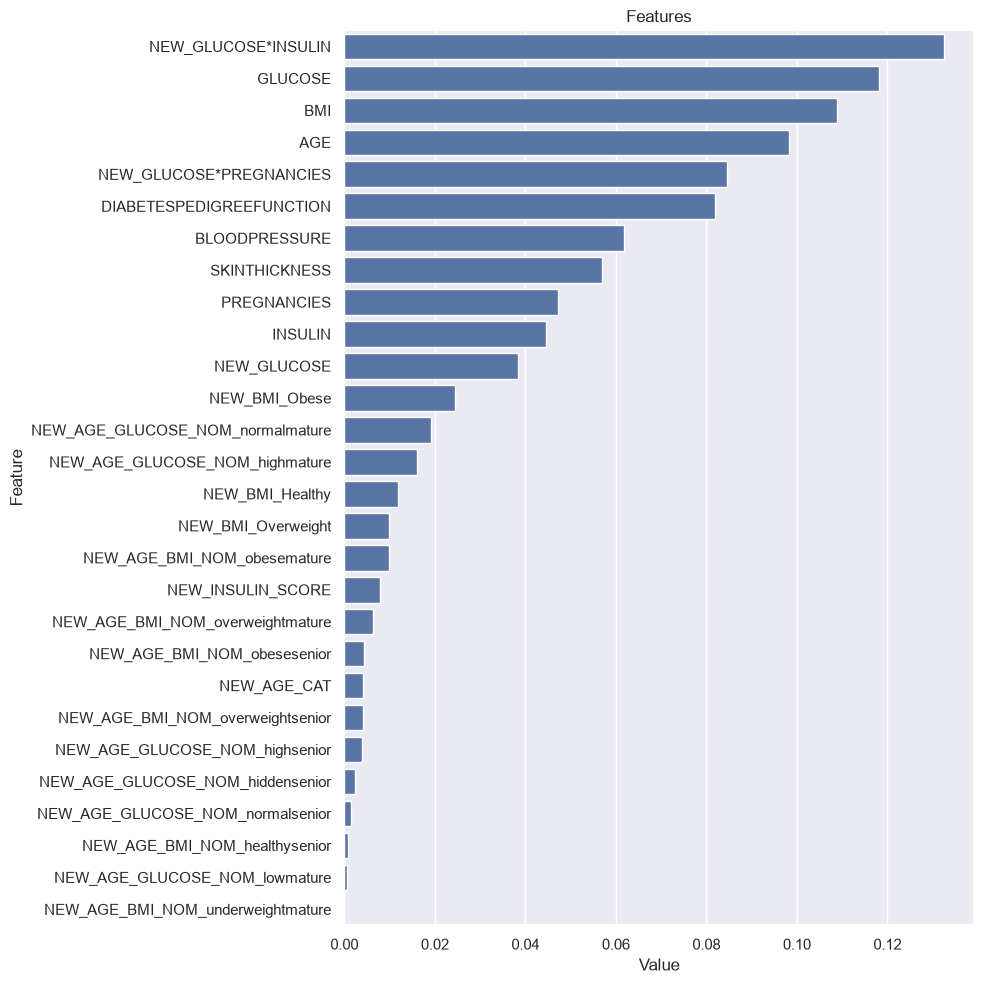

In [ ]:
# Özellik (feature) önemlerini görselleştiren bir fonksiyon tanımlıyoruz.
# Modelin hangi değişkenlere daha fazla önem verdiğini analiz etmek için bu fonksiyon kullanılır.
def plot_importance(model, features, num=len(X), save=False):
    # Modelin bağımsız değişkenlere atadığı önem skorlarını bir tabloya döküyoruz.
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    # Önemi yüksek olan özellikler en üstte gözükecek şekilde tabloyu sıralayıp ekrana basıyoruz.
    print(feature_imp.sort_values("Value", ascending=False))
    # Grafik boyutunu ayarlıyoruz.
    plt.figure(figsize=(10, 10))
    # Görseldeki yazı büyüklüğünü ayarlıyoruz.
    sns.set(font_scale=1)
    # Özelliklerin önem skoruna göre yatay bir çubuk grafik çiziyoruz.
    # En önemli (en yüksek skor) değişkenler yukarıda gözükecek şekilde sıralıyoruz.
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value",
                                                                     ascending=False)[0:num])
    # Grafik başlığını ekliyoruz.
    plt.title('Features')
    # Grafik görselinin düzgün çıkmasını sağlıyoruz.
    plt.tight_layout()
    # Grafiği ekrana gösteriyoruz.
    plt.show()
    # Eğer istenirse görseli kaydediyoruz.
    if save:
        plt.savefig('importances.png')

# Rastgele Orman modelinin, hangi değişkenlere daha çok önem verdiğini görselleştiriyoruz.
plot_importance(rf_model, X)